In [2]:
import spacy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
import sys, os
sys.path.append(os.path.abspath('../../../..'))
from src.data.mongo_storage import _get_default_collection

# Cargar canciones desde MongoDB incluyendo pos_tags ya calculados
col = _get_default_collection()
docs = list(col.find(
    {'pos_tags.spacy': {'$ne': None}},
    {'_id': 1, 'Song': 1, 'Artist': 1, 'Genre': 1,
     'Song year': 1, 'Lyrics': 1, 'Language': 1,
     'pos_tags': 1}
))

df = pd.DataFrame(docs)
# pos_tags.spacy ya viene como lista de dicts desde Mongo, no necesita literal_eval
df['pos_tags_spacy'] = df['pos_tags'].apply(
    lambda x: x['spacy'] if isinstance(x, dict) and 'spacy' in x else []
)
print(f'✓ {len(df)} canciones cargadas desde MongoDB con pos_tags')
df.head()


✓ 7935 canciones cargadas desde MongoDB con pos_tags


,_id,Artist,Genre,Language,Lyrics,Song,Song year,pos_tags,pos_tags_spacy
0,69c50c3b73a7e31576c65131,buck-65,Hip-Hop,en,Most folks spend their days daydreaming of fin...,craftsmanship,2005,"{'nltk': [{'token': 'Most', 'tag': 'JJS'}, {'t...","[{'token': 'Most', 'pos': 'ADJ', 'tag': 'JJS',..."
1,69c50c3b73a7e31576c65132,the-elwins,Indie,en,Take your cold hands and put them on my face S...,come-on-out,2012,"{'nltk': [{'token': 'Take', 'tag': 'VB'}, {'to...","[{'token': 'Take', 'pos': 'VERB', 'tag': 'VB',..."
2,69c50c3b73a7e31576c65133,bullet-for-my-valentine,Metal,en,Are you ready its time for war Well break down...,riot,2013,"{'nltk': [{'token': 'Are', 'tag': 'NNP'}, {'to...","[{'token': 'Are', 'pos': 'AUX', 'tag': 'VBP', ..."
3,69c50c3b73a7e31576c65134,dream-street,Pop,en,You ask me why I change the color of my hair Y...,that-s-what-girls-do,2007,"{'nltk': [{'token': 'You', 'tag': 'PRP'}, {'to...","[{'token': 'You', 'pos': 'PRON', 'tag': 'PRP',..."
4,69c50c3b73a7e31576c65135,cassidy,Hip-Hop,en,Do you believe in magic in a young girls heart...,believe-in-a-dollar,2012,"{'nltk': [{'token': 'Do', 'tag': 'VBP'}, {'tok...","[{'token': 'Do', 'pos': 'AUX', 'tag': 'VBP', '..."


In [3]:
def extract_pos_counts(pos_tags):
    """
    Usa los pos_tags ya almacenados en MongoDB (lista de dicts con
    'token', 'pos', 'tag', 'lemma') para contar categorías morfosintácticas.
    """
    if not pos_tags:
        return None

    counts = {
        'total_words': 0,
        'verbs': 0,
        'nouns': 0,
        'adjectives': 0,
        'adverbs': 0,
        'pronouns': 0,
        'proper_nouns': 0,
        'action_verbs': 0,
        'relational_verbs': 0,
        'present_verbs': 0,
        'gerund_verbs': 0,
        'first_person_pronouns': 0,
        'second_person_pronouns': 0,
        'third_person_pronouns': 0,
    }

    action_verbs = {'run', 'jump', 'fight', 'win', 'lose', 'dance', 'sing', 'talk', 'say', 'do'}
    relational_verbs = {'be', 'have', 'seem', 'become', 'remain', 'stay', 'appear', 'feel'}
    first_person  = {'i', 'me', 'my', 'mine', 'myself', 'we', 'us', 'our', 'ours', 'ourselves'}
    second_person = {'you', 'your', 'yours', 'yourself', 'yourselves'}
    third_person  = {'he', 'him', 'his', 'himself', 'she', 'her', 'hers', 'herself',
                     'it', 'its', 'itself', 'they', 'them', 'their', 'theirs', 'themselves'}

    for t in pos_tags:
        pos   = t.get('pos', '')
        tag   = t.get('tag', '')
        lemma = t.get('lemma', '').lower()
        token = t.get('token', '').lower()

        if pos in ('PUNCT', 'SPACE'):
            continue

        counts['total_words'] += 1

        if pos == 'VERB':
            counts['verbs'] += 1
            if tag in ('VBP', 'VBZ'):           # presente simple
                counts['present_verbs'] += 1
            if tag == 'VBG':                     # gerundio
                counts['gerund_verbs'] += 1
            if lemma in action_verbs:
                counts['action_verbs'] += 1
            if lemma in relational_verbs:
                counts['relational_verbs'] += 1
        elif pos == 'NOUN':
            counts['nouns'] += 1
        elif pos == 'PROPN':
            counts['proper_nouns'] += 1
        elif pos == 'ADJ':
            counts['adjectives'] += 1
        elif pos == 'ADV':
            counts['adverbs'] += 1
        elif pos == 'PRON':
            counts['pronouns'] += 1
            if token in first_person:
                counts['first_person_pronouns'] += 1
            elif token in second_person:
                counts['second_person_pronouns'] += 1
            elif token in third_person:
                counts['third_person_pronouns'] += 1

    return counts


In [4]:
from tqdm import tqdm

pos_columns = ['total_words', 'verbs', 'nouns', 'adjectives', 'adverbs', 'pronouns',
               'proper_nouns', 'action_verbs', 'relational_verbs', 'present_verbs',
               'gerund_verbs', 'first_person_pronouns', 'second_person_pronouns',
               'third_person_pronouns']

for col_name in pos_columns:
    df[col_name] = 0

# Usar pos_tags ya almacenados en MongoDB, no re-procesar desde Lyrics
for idx, tags in tqdm(df['pos_tags_spacy'].items(), total=len(df)):
    counts = extract_pos_counts(tags)
    if counts:
        for col_name in pos_columns:
            df.at[idx, col_name] = counts[col_name]

print(f'✓ Métricas extraídas de {len(df)} canciones desde pos_tags de MongoDB')
df[pos_columns].head()


100%|██████████| 7935/7935 [00:01<00:00, 4663.06it/s]

✓ Métricas extraídas de 7935 canciones desde pos_tags de MongoDB


,total_words,verbs,nouns,adjectives,adverbs,pronouns,proper_nouns,action_verbs,relational_verbs,present_verbs,gerund_verbs,first_person_pronouns,second_person_pronouns,third_person_pronouns
0,427,70,79,32,20,67,4,8,1,27,8,21,16,14
1,293,66,40,16,11,64,5,8,3,25,8,15,31,6
2,204,40,28,5,10,22,17,8,3,8,2,2,4,11
3,229,47,27,14,6,63,0,2,3,16,6,16,22,11
4,249,37,48,10,13,40,7,0,2,9,0,6,23,9


In [5]:

# Densities per 1000 words
df['action_verbs_per1k'] = df['action_verbs'] / df['total_words'] * 1000
df['relational_verbs_per1k'] = df['relational_verbs'] / df['total_words'] * 1000
df['present_verbs_per1k'] = df['present_verbs'] / df['total_words'] * 1000
# ... similarly for other metrics

## Longitud promedio por género

In [6]:
print(df.columns)

Index(['_id', 'Artist', 'Genre', 'Language', 'Lyrics', 'Song', 'Song year',
       'pos_tags', 'pos_tags_spacy', 'total_words', 'verbs', 'nouns',
       'adjectives', 'adverbs', 'pronouns', 'proper_nouns', 'action_verbs',
       'relational_verbs', 'present_verbs', 'gerund_verbs',
       'first_person_pronouns', 'second_person_pronouns',
       'third_person_pronouns', 'action_verbs_per1k', 'relational_verbs_per1k',
       'present_verbs_per1k'],
      dtype='object')


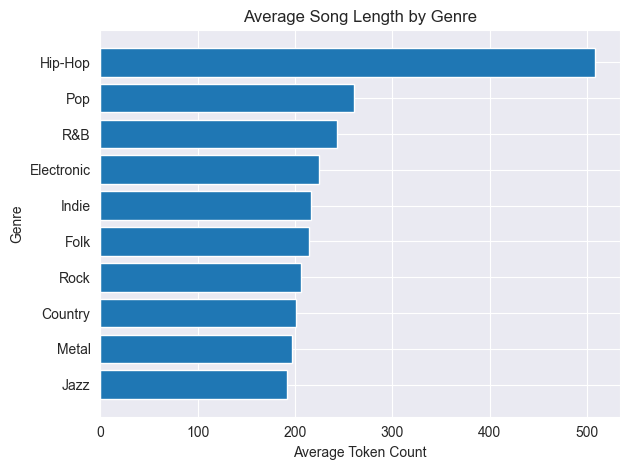

In [7]:
genre_length = df.groupby('Genre')['total_words'].mean().sort_values()

plt.figure()
plt.barh(genre_length.index, genre_length.values)
plt.xlabel("Average Token Count")
plt.ylabel("Genre")
plt.title("Average Song Length by Genre")
plt.tight_layout()
plt.show()


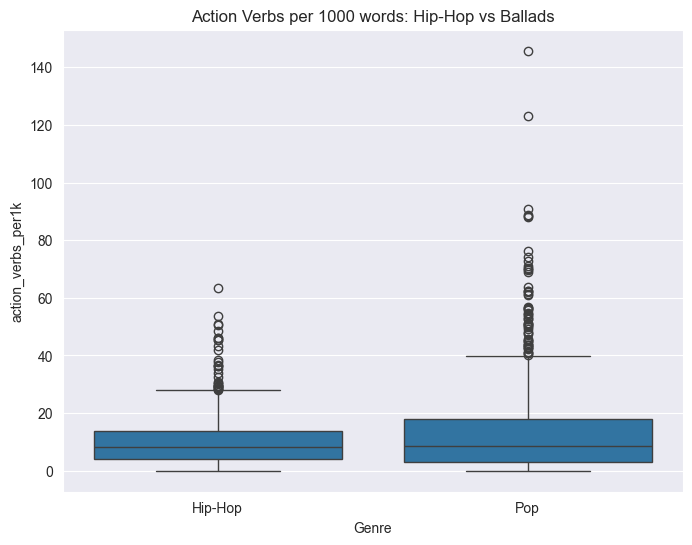

T-test: t=-5.996, p=0.000
Significant difference.


In [8]:
# Filter genres
hiphop = df[df['Genre'] == 'Hip-Hop']['action_verbs_per1k'].dropna()
ballads = df[df['Genre'] == 'Pop']['action_verbs_per1k'].dropna()

# Plot
plt.figure(figsize=(8,6))
sns.boxplot(data=df[df['Genre'].isin(['Hip-Hop', 'Pop'])], x='Genre', y='action_verbs_per1k')
plt.title('Action Verbs per 1000 words: Hip-Hop vs Ballads')
plt.show()

# T-test
t_stat, p_val = ttest_ind(hiphop, ballads, equal_var=False)
print(f"T-test: t={t_stat:.3f}, p={p_val:.3f}")
if p_val < 0.05:
    print("Significant difference.")
else:
    print("No significant difference.")

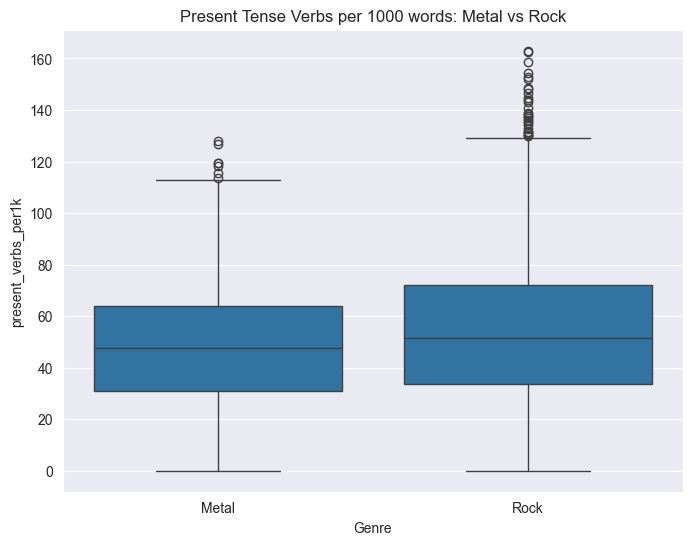

In [9]:
reggaeton = df[df['Genre'] == 'Metal']['present_verbs_per1k'].dropna()
rock = df[df['Genre'] == 'Rock']['present_verbs_per1k'].dropna()

plt.figure(figsize=(8,6))
sns.boxplot(data=df[df['Genre'].isin(['Metal', 'Rock'])], x='Genre', y='present_verbs_per1k')
plt.title('Present Tense Verbs per 1000 words: Metal vs Rock')
plt.show()



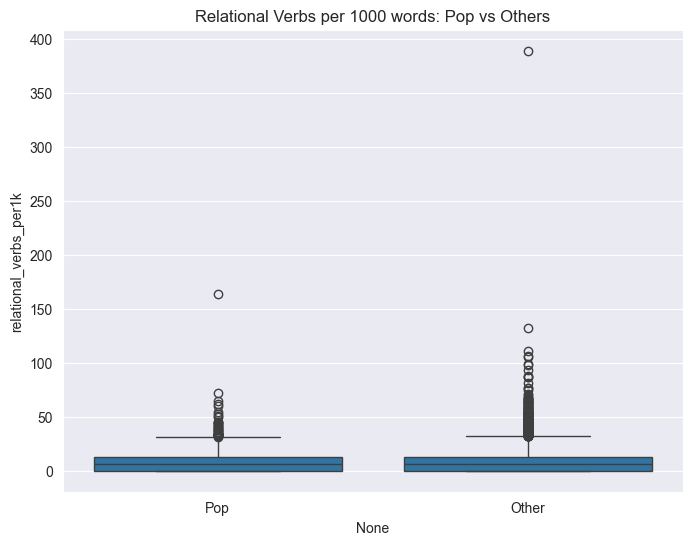

T-test: t=2.146, p=0.032


In [10]:
# Compare Pop with all other genres combined
pop = df[df['Genre'] == 'Pop']['relational_verbs_per1k'].dropna()
others = df[df['Genre'] != 'Pop']['relational_verbs_per1k'].dropna()

plt.figure(figsize=(8,6))
sns.boxplot(x=pd.Series(['Pop']*len(pop) + ['Other']*len(others)), y=pd.concat([pop, others]))
plt.title('Relational Verbs per 1000 words: Pop vs Others')
plt.show()

t_stat, p_val = ttest_ind(pop, others, equal_var=False)
print(f"T-test: t={t_stat:.3f}, p={p_val:.3f}")

## Número de canciones por género

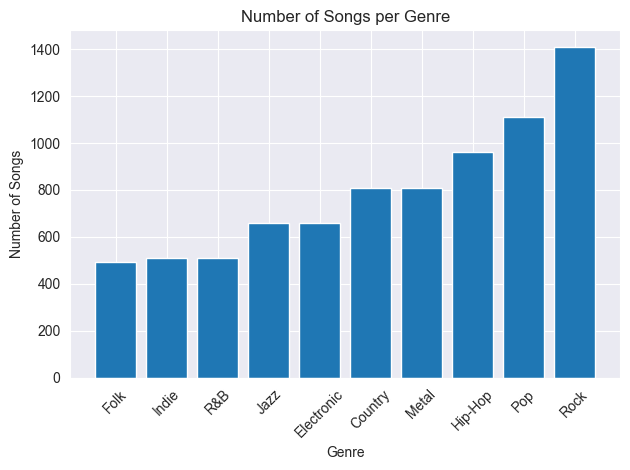

In [11]:
genre_counts = df['Genre'].value_counts().sort_values()

plt.figure()
plt.bar(genre_counts.index, genre_counts.values)
plt.xlabel("Genre")
plt.ylabel("Number of Songs")
plt.title("Number of Songs per Genre")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()